In [8]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

In [9]:
all_sample_sep_m_meta_path="../../results/S4/all_sample_sep_m_meta.txt"
output_path <- "../../results/S5"
create_path(output_path)
orfs_path <- "../../results/orfs_merged_final.tsv"
fread_c(orfs_path) -> orfs
# orfs %>% filter(ORF_length<=150) -> orfs

In [23]:
# 增加frame0的比例
fread_c("/home/user/data3/lit/project/sORFs/10-feature-egi/processed/feature_preprare/peri/psite_frame_stats.v2.tsv") -> orfs_peri
head(orfs_peri,1)

,ORF_id,CDS_nt_len,n_codons,frame0,frame1,frame2,total_psites,frame0_fraction,frame0_codon_covered
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,PB.41013.1:chr6:+|1|330:5:44|noncoding|GTG,36,12,0,0,0,0,0,0


In [24]:
nrow(orfs_peri)

[1] 13789861

In [33]:
nrow(orfs)
colnames(orfs)
orfs[grepl("^PB",orfs$ORF_id),] %>% nrow()
table(orfs$Is_canonical)

[1] 27860

[1] "ORF_id"                            "ORF_type"                         
 [3] "Start_codon"                       "Isoform_id"                       
 [5] "Chr"                               "Strand"                           
 [7] "ORF_seq"                           "ORF_length"                       
 [9] "Geneid"                            "Isoform_structural_category"      
[11] "Isoform_subcategory"               "Is_uniprot"                       
[13] "Is_canonical"                      "Run_occurrence"                   
[15] "RPF_reads"                         "Psites_number"                    
[17] "RPF_RPKM"                          "Psites_RPKM"                      
[19] "RPF_codon_coverage"                "Psites_codon_coverage"            
[21] "FL"                                "FL_TPM"                           
[23] "N"                                 "C"                                
[25] "A"                                 "Gene_type"                        
[27] "Unique_peptide_n"                  "Unique_peptide_n_msfragger_closed"
[29] "mean_relative_iBAQ"

[1] 27613


FALSE  TRUE 
17681 10179 

In [42]:
filter(orfs,ORF_id=="PB.36221.103:chr4:-|8|2732:98:212|uORF|ATG") %>% print()

                                      ORF_id ORF_type Start_codon   Isoform_id
1 PB.36221.103:chr4:-|8|2732:98:212|uORF|ATG     uORF         ATG PB.36221.103
   Chr Strand                               ORF_seq ORF_length  Geneid
1 chr4      - MPLHQISVIPARETASNGRNSMGRNKEKNKEVENFRN         37 MARCHF1
  Isoform_structural_category            Isoform_subcategory Is_uniprot
1            novel_in_catalog combination_of_known_junctions      FALSE
  Is_canonical Run_occurrence RPF_reads Psites_number RPF_RPKM Psites_RPKM
1        FALSE             16       211           136 0.125629    0.115414
  RPF_codon_coverage Psites_codon_coverage FL   FL_TPM        N        C
1             5.7027               3.67568  3 0.410029 2.702042 7.108785
         A      Gene_type Unique_peptide_n Unique_peptide_n_msfragger_closed
1 4.905413 protein_coding                2                                 2
  mean_relative_iBAQ
1       0.0001785053


In [25]:
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    df %>% mutate(Sample=NULL) %>% rename(Sample=Sample_merge_replicate) -> df_1
    return(df_1)
}

fread_c(all_sample_sep_m_meta_path) -> all_sample_sep_m_meta

df <- merge_replicate(all_sample_sep_m_meta)
protein_stats_v1 <- df %>%
  group_by(Protein) %>%
  summarise(
    Unique_Methods = n_distinct(Enrichment),  # 被多少种不同富集方法鉴定到
    Unique_Enzymes = n_distinct(Enzyme),  # 被多少种不同酶切方法鉴定到
    Total_Observations = n(),                 # 被鉴定到的总次数
    Supported_Enrichments = paste(sort(unique(Enrichment)), collapse = ", "),  # 支持的富集方法（去重后逗号分隔）
    Supported_Enzymes = paste(sort(unique(Enzyme)), collapse = ", ")  # 支持的酶切方法（去重后逗号分隔）
  )
  
fwrite_c(protein_stats_v1[,"Protein"],o("protein.id.txt"))
  
  # 得到蛋白质对应的序列
# system("bash S5.bio.sh")
# read.table(o("protein.id.tab")) -> protein_id_seq
orfs[,c("ORF_id","ORF_seq")]  -> protein_id_seq
colnames(protein_id_seq) <- c("Protein","Seq")
merge(protein_stats_v1,protein_id_seq,by="Protein") -> protein_stats_v1_a_seq

protein_stats_v1_a_seq %>% filter(Unique_Methods==1|Unique_Methods==5) -> unique_methods_protein
unique_methods_protein[,c("Protein","Seq","Supported_Enrichments")] -> unique_methods_protein_df
table(unique_methods_protein_df$Supported_Enrichments)
fwrite_c(unique_methods_protein_df,o("unique_methods_protein.txt"))

protein_stats_v1_a_seq %>% filter(Unique_Enzymes==1) -> unique_enzymes_protein
unique_enzymes_protein[,c("Protein","Seq","Supported_Enzymes")] -> unique_enzymes_protein_df
fwrite_c(unique_enzymes_protein_df,o("unique_enzymes_protein.txt"))


                                C8 C8, MWCO, No_enrichment, PAGE, PCP 
                              3916                               1823 
                              MWCO                      No_enrichment 
                              1735                               3747 
                              PAGE                                PCP 
                              1054                               6251 

In [40]:
head(protein_stats_v1)
nrow(protein_stats_v1)
set.seed(123)
protein_stats_v1 %>% filter(Supported_Enrichments=="MWCO")  %>% 
filter(!grepl("canonical",Protein)) %>% 
filter(grepl("\\bTrypsin\\b", Supported_Enzymes)) %>% 
slice_sample(n = 10)

Protein,Unique_Methods,Unique_Enzymes,Total_Observations,Supported_Enrichments,Supported_Enzymes
<chr>,<int>,<int>,<int>,<chr>,<chr>
PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,1,1,1,No_enrichment,Trypsin
PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,1,1,1,No_enrichment,Trypsin
PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,1,1,1,PCP,Trypsin_GluC
PB.1001.12:chr1:-|8|2625:155:2039|canonical|ATG,1,1,1,No_enrichment,Trypsin
PB.1001.3:chr1:-|9|2745:169:253|iORF|ACG,2,2,2,"No_enrichment, PCP","Trypsin, Trypsin_AspN"
PB.1001.41:chr1:-|217|3689:2936:2990|noncoding|GTG,1,1,1,C8,Trypsin_LysC


[1] 27613

Protein,Unique_Methods,Unique_Enzymes,Total_Observations,Supported_Enrichments,Supported_Enzymes
<chr>,<int>,<int>,<int>,<chr>,<chr>
PB.36221.103:chr4:-|8|2732:98:212|uORF|ATG,1,7,16,MWCO,"Trypsin, Trypsin_ArgC, Trypsin_AspN, Trypsin_Chymotrypsin, Trypsin_GluC, Trypsin_LysC, Trypsin_LysN"
PB.11741.1:chr12:-|75|2705:976:1276|dORF|ACG,1,1,1,MWCO,Trypsin
PB.38608.4:chr5:-|174|4038:3038:3329|dORF|ATG,1,2,2,MWCO,"Trypsin, Trypsin_LysN"
PB.7892.20:chr11:-|4|1959:132:750|noncoding|ATG,1,1,2,MWCO,Trypsin
PB.265.57:chr1:+|70|2153:923:1046|noncoding|TTG,1,1,1,MWCO,Trypsin
PB.7648.11:chr11:+|58|1242:982:1210|dORF|CTG,1,1,1,MWCO,Trypsin
PB.43182.12:chr7:+|52|2391:809:1391|noncoding|ATG,1,4,4,MWCO,"Trypsin, Trypsin_ArgC, Trypsin_Chymotrypsin, Trypsin_LysN"
PB.46495.54:chr8:-|210|3345:3034:3088|noncoding|ATG,1,1,1,MWCO,Trypsin
PB.98.12:chr1:-|74|1428:874:991|noncoding|CTG,1,1,1,MWCO,Trypsin


# 统计只被一种富集方法检测到的蛋白质的三碱基周期性

In [31]:
merge(protein_stats_v1,orfs_peri,by.x="Protein",by.y="ORF_id") -> protein_stats_v1_merge_with_frame0

In [35]:
nrow(protein_stats_v1_merge_with_frame0)
head(protein_stats_v1_merge_with_frame0)

[1] 27613

,Protein,Unique_Methods,Unique_Enzymes,Total_Observations,Supported_Enrichments,Supported_Enzymes,CDS_nt_len,n_codons,frame0,frame1,frame2,total_psites,frame0_fraction,frame0_codon_covered
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,1,1,1,No_enrichment,Trypsin,348,116,17,1,2,20,0.850000,6
2,PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,1,1,1,No_enrichment,Trypsin,180,60,10,0,0,10,1.000000,2
3,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,1,1,1,PCP,Trypsin_GluC,63,21,17,12,0,29,0.586207,4
4,PB.1001.12:chr1:-|8|2625:155:2039|canonical|ATG,1,1,1,No_enrichment,Trypsin,1881,627,5978,624,308,6910,0.865123,282
5,PB.1001.3:chr1:-|9|2745:169:253|iORF|ACG,2,2,2,"No_enrichment, PCP","Trypsin, Trypsin_AspN",81,27,24,2,22,48,0.500000,4
6,PB.1001.41:chr1:-|217|3689:2936:2990|noncoding|GTG,1,1,1,C8,Trypsin_LysC,51,17,1,1,0,2,0.500000,1


In [68]:
library(dplyr)
library(ggplot2)
library(ggpubr) # 用于添加显著性标记

# 1. 预处理数据：创建一个新的分组列
protein_stats_v1_merge_with_frame0  %>% filter(!grepl("canonical",Protein)) -> df
nrow(df)
df_plot <- df %>%
  mutate(Method_Group = ifelse(Unique_Methods == 1, "Single Method", "Multiple Methods")) %>%
  filter(!is.na(frame0_fraction)) # 剔除空值
head(df_plot)
table(df_plot$Method_Group)
# 2. 统计描述
summary_stats <- df_plot %>%
  group_by(Method_Group) %>%
  summarise(
    Mean = mean(frame0_fraction),
    Median = median(frame0_fraction),
    Count = n()
  )
summary_stats
# 3. 显著性检验
stat_test <- wilcox.test(frame0_fraction ~ Method_Group, data = df_plot)
print(stat_test)

[1] 17681

,Protein,Unique_Methods,Unique_Enzymes,Total_Observations,Supported_Enrichments,Supported_Enzymes,CDS_nt_len,n_codons,frame0,frame1,frame2,total_psites,frame0_fraction,frame0_codon_covered,Method_Group
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>
1,PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,1,1,1,No_enrichment,Trypsin,348,116,17,1,2,20,0.850000,6,Single Method
2,PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,1,1,1,No_enrichment,Trypsin,180,60,10,0,0,10,1.000000,2,Single Method
3,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,1,1,1,PCP,Trypsin_GluC,63,21,17,12,0,29,0.586207,4,Single Method
4,PB.1001.3:chr1:-|9|2745:169:253|iORF|ACG,2,2,2,"No_enrichment, PCP","Trypsin, Trypsin_AspN",81,27,24,2,22,48,0.500000,4,Multiple Methods
5,PB.1001.41:chr1:-|217|3689:2936:2990|noncoding|GTG,1,1,1,C8,Trypsin_LysC,51,17,1,1,0,2,0.500000,1,Single Method
6,PB.10020.13:chr12:+|22|1011:465:531|noncoding|ATG,1,4,4,PCP,"Trypsin, Trypsin_ArgC, Trypsin_GluC, Trypsin_LysC",63,21,4,0,4,8,0.500000,2,Single Method



Multiple Methods    Single Method 
            3547            14134 

Method_Group,Mean,Median,Count
<chr>,<dbl>,<dbl>,<int>
Multiple Methods,0.7432483,0.758621,3547
Single Method,0.7272821,0.700000,14134



	Wilcoxon rank sum test with continuity correction

data:  frame0_fraction by Method_Group
W = 26763263, p-value = 3.906e-10
alternative hypothesis: true location shift is not equal to 0



In [65]:
summary(df_plot$frame0_fraction)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.5000  0.5789  0.7143  0.7305  0.8643  1.0000 

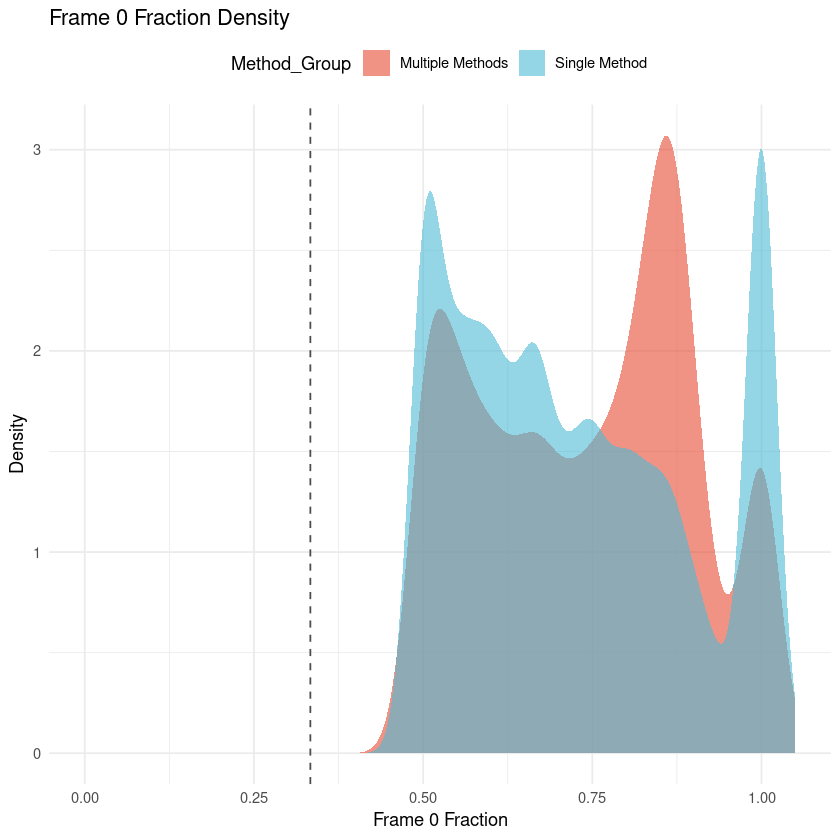

In [64]:
p <- ggplot(df_plot, aes(x = frame0_fraction, fill = Method_Group)) +
  
  # 核心函数：alpha 设置透明度，防止遮挡
  geom_density(alpha = 0.6, color = NA) + 
  
  # 添加 1/3 (0.33) 随机参考线
  geom_vline(xintercept = 1/3, linetype = "dashed", color = "grey30") +
  
  # 手动配色 (蓝 vs 红)
  scale_fill_manual(values = c("Multiple Methods" = "#E64B35", "Single Method" = "#4DBBD5")) +
  
  # 坐标轴与标签
  labs(title = "Frame 0 Fraction Density",
       x = "Frame 0 Fraction",
       y = "Density") +
  
  # 限制范围 (0-1)
  scale_x_continuous(limits = c(0, 1.05)) +
  
  # 简约主题
  theme_minimal() +
  theme(legend.position = "top") # 图例放上面比较不占位置

print(p)

# 统计run_occurance

In [63]:
merge(protein_stats_v1,orfs,by.x="Protein",by.y="ORF_id")-> protein_stats_v1_merge_with_orfs
protein_stats_v1_merge_with_orfs  %>% filter(!grepl("canonical",Protein)) -> protein_stats_v1_merge_with_orfs_1
nrow(protein_stats_v1_merge_with_orfs_1)
protein_stats_v1_merge_with_orfs_1 %>% filter(Unique_Methods==1) -> df_2_run_occ
nrow(df_2_run_occ)
filter(df_2_run_occ,Run_occurrence>1) %>% nrow()

[1] 17681

[1] 14134

[1] 2105

In [67]:
protein_stats_v1_merge_with_orfs_1 %>% filter(Unique_Methods>1) -> df_2_run_occ
nrow(df_2_run_occ)
filter(df_2_run_occ,Run_occurrence>1) %>% nrow()

[1] 3547

[1] 3547

In [1]:
chisq.test(matrix(c(9280, 652, 11897, 5784), nrow = 2))


	Pearson's Chi-squared test with Yates' continuity correction

data:  matrix(c(9280, 652, 11897, 5784), nrow = 2)
X-squared = 2431.1, df = 1, p-value < 2.2e-16
